## **Leaflet monthly print-run aggregator + basic statistics & visualization**
- Upload a ZIP archive containing .txt files (filenames only are parsed)
- User defines the value to substitute for unknown print runs ('unk')
- Aggregates print runs per month (YYYY-MM)
- Computes mean, median, ANOVA and Kruskal–Wallis tests
- Saves CSV output and plots bar charts, heatmaps, and cumulative plots

In [42]:
#@title 0) Import libraries
import zipfile
import io
import os
import re
import csv
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns
import pandas as pd
from google.colab import files

In [43]:
#@title 1) Upload ZIP file
print("Upload a ZIP file containing .txt leaflet files.")
uploaded = files.upload()
if not uploaded:
    raise SystemExit("No file uploaded.")
zip_name = next(iter(uploaded.keys()))
zip_bytes = uploaded[zip_name]

Upload a ZIP file containing .txt leaflet files.


Saving LCLC_1934-1940_all_leaflets_with_variations_and_with_no_text.zip to LCLC_1934-1940_all_leaflets_with_variations_and_with_no_text (3).zip


In [44]:
#@title 2) Extract filenames from ZIP
z = zipfile.ZipFile(io.BytesIO(zip_bytes))
txt_members = [m for m in z.infolist() if m.filename.lower().endswith('.txt')]
if not txt_members:
    raise SystemExit("No .txt files found in ZIP.")
filenames = [os.path.basename(m.filename) for m in txt_members]

# --- NEW: read metadata from file contents (print_run, production_method, date -> YYYY-MM) ---

META_LINE_RE = re.compile(r'^(?P<key>[a-zA-Z0-9_]+)\s*:\s*(?P<val>.*)\s*$')

def parse_metadata_from_text(full_text: str) -> dict:
    meta = {}
    for line in full_text.splitlines():
        # stop at text field
        if line.strip().lower().startswith("text"):
            break
        m = META_LINE_RE.match(line.strip())
        if m:
            meta[m.group("key").strip()] = m.group("val").strip()
    return meta

def norm_print_run(v: str):
    if v is None:
        return "unk"
    v = v.strip().lower()
    if v in ("unk", "?", ""):
        return "unk"
    digits = re.sub(r"[^\d]", "", v)
    return int(digits) if digits else "unk"

def norm_prod_method(v: str):
    if v is None:
        return "unk"
    v = v.strip().lower()
    if v in ("", "unk", "?"):
        return "unk"
    return v  # expected: typographic / rotator / shapirograph

def extract_year_month_from_date_field(date_val: str):
    if not date_val:
        return None
    m = re.search(r"(19\d{2})-(\d{2})", date_val)
    return f"{m.group(1)}-{m.group(2)}" if m else None

# Build metadata dict keyed by BASENAME filename (matches `filenames`)
meta_by_fname = {}
for m in txt_members:
    fname = os.path.basename(m.filename)
    raw = z.read(m).decode("utf-8", errors="replace")
    meta = parse_metadata_from_text(raw)
    meta_by_fname[fname] = {
        "print_run": norm_print_run(meta.get("print_run")),
        "production_method": norm_prod_method(meta.get("production_method")),
        "date_raw": meta.get("date", ""),
        "year_month": extract_year_month_from_date_field(meta.get("date", "")),
    }


In [45]:
#@title 3) Impute 'unk' print_run as median per production_method
known_rows = []
for fname in filenames:
    pr = meta_by_fname.get(fname, {}).get("print_run", "unk")
    pm = meta_by_fname.get(fname, {}).get("production_method", "unk")
    if isinstance(pr, int):
        known_rows.append((pm, pr))

df_known = pd.DataFrame(known_rows, columns=["production_method", "print_run"])

# Medians by method (only from known numeric print runs)
med_by_pm = df_known.groupby("production_method")["print_run"].median().to_dict()

# Fallback: global median among all known numeric print runs
global_median = int(df_known["print_run"].median()) if not df_known.empty else 1000

print("Median print_run by production_method (known only):", {k: int(v) for k, v in med_by_pm.items()})
print("Global median fallback:", global_median)

def impute_print_run(fname: str) -> int:
    pr = meta_by_fname.get(fname, {}).get("print_run", "unk")
    pm = meta_by_fname.get(fname, {}).get("production_method", "unk")
    if isinstance(pr, int):
        return pr
    # unknown print run -> use median of its production_method (if available) else global median
    if pm in med_by_pm and not np.isnan(med_by_pm[pm]):
        return int(med_by_pm[pm])
    return global_median


Median print_run by production_method (known only): {'rotator': 2000, 'shapirograph': 300, 'typographic': 5000, 'unk': 2000}
Global median fallback: 3000


In [46]:
#@title 4) Helper functions for extracting year-month and print run (from file metadata)

def extract_print_run(fname):
    """Extract print_run from inside-file metadata. Returns int or 'unk'."""
    return meta_by_fname.get(fname, {}).get("print_run", None)

def extract_year_month(fname):
    """Extract YYYY-MM from inside-file metadata date field."""
    return meta_by_fname.get(fname, {}).get("year_month", None)


In [47]:
#@title 5) Aggregate print runs by month
monthly_totals = defaultdict(int)   # total print run per month
monthly_counts = defaultdict(int)   # number of leaflets per month
monthly_values = defaultdict(list)  # list of all print runs per month
unassigned = []

for fname in filenames:
    pr = extract_print_run(fname)
    ym = extract_year_month(fname)
    if ym is None:
        unassigned.append(fname)
        continue

    val = impute_print_run(fname)  # <<< NEW: median-by-production_method imputation
    monthly_totals[ym] += val
    monthly_counts[ym] += 1
    monthly_values[ym].append(val)

if unassigned:
    print("Files with NO parsed 19xx year-month in metadata (skipped):")
    for u in unassigned:
        print("  ", u)
    print()


Files with NO parsed 19xx year-month in metadata (skipped):
   lclc_ex-n064x-LKP_I_district-200-1934.txt
   lclc_ex-n065x-LKP_LKJS_Ventspils_district_committees-1500-1934.txt
   lclc_ex-n114x-LKP_CK-10000-1935.txt
   lclc_ex-n115x-LKP_Riga_committee-15000-1935.txt
   lclc_ex-n116x-LKP_Riga_committee-15000-1935.txt
   lclc_ex-n117x-LKP_Riga_committee-15000-1935.txt
   lclc_ex-n118x-LKP_Riga_committee-15000-1935.txt
   lclc_ex-n119x-LKP_Riga_committee-15000-1935.txt
   lclc_ex-n120x-LKP_Riga_committee-15000-1935.txt
   lclc_ex-n121x-LKP_Riga_committee-15000-1935.txt
   lclc_ex-n122x-LKP_Riga_committee-15000-1935.txt
   lclc_ex-n123x-LKP_Riga_org_students_faction-150-1935.txt
   lclc_ex-n124x-LKP_Liepaja_org_transport_workers_district-unk-1935.txt
   lclc_ex-n125x-LKP_Riga_org_West_district_committee-500-1935.txt
   lclc_ex-n126x-LSSZP_CK-2500-1935.txt
   lclc_ex-n127x-Latvian_Revolutionary_Writers_Artists_Journalists_Association_Central_Board-500-1935.txt
   lclc_ex-n128x-Latvian_Revolut

In [48]:
#@title 6) Sort months chronologically
def ym_sort_key(ym):
    y, m = ym.split('-')
    return (int(y), int(m))
sorted_months = sorted(monthly_totals.keys(), key=ym_sort_key)

In [49]:
#@title 7) Compute mean & median per month
print("\n=== Monthly statistics ===")
summary = []
for ym in sorted_months:
    vals = monthly_values[ym]
    mean = np.mean(vals)
    median = np.median(vals)
    summary.append((ym, monthly_totals[ym], monthly_counts[ym], mean, median))
    print(f"{ym}: total={monthly_totals[ym]}, n={monthly_counts[ym]}, mean={mean:.1f}, median={median}")


=== Monthly statistics ===
1934-01: total=27700, n=11, mean=2518.2, median=2000.0
1934-02: total=39400, n=13, mean=3030.8, median=2000.0
1934-03: total=22500, n=8, mean=2812.5, median=2000.0
1934-04: total=46700, n=16, mean=2918.8, median=2000.0
1934-05: total=52000, n=21, mean=2476.2, median=2000.0
1934-06: total=8550, n=6, mean=1425.0, median=2000.0
1934-07: total=44400, n=20, mean=2220.0, median=2000.0
1934-08: total=27350, n=12, mean=2279.2, median=2000.0
1934-09: total=24750, n=12, mean=2062.5, median=1250.0
1934-10: total=30630, n=18, mean=1701.7, median=2000.0
1934-11: total=47000, n=13, mean=3615.4, median=3000.0
1934-12: total=23770, n=11, mean=2160.9, median=1500.0
1935-01: total=34850, n=17, mean=2050.0, median=2000.0
1935-02: total=55850, n=21, mean=2659.5, median=2000.0
1935-03: total=37900, n=16, mean=2368.8, median=2000.0
1935-04: total=73100, n=16, mean=4568.8, median=4000.0
1935-05: total=68100, n=20, mean=3405.0, median=3500.0
1935-06: total=7700, n=4, mean=1925.0, m

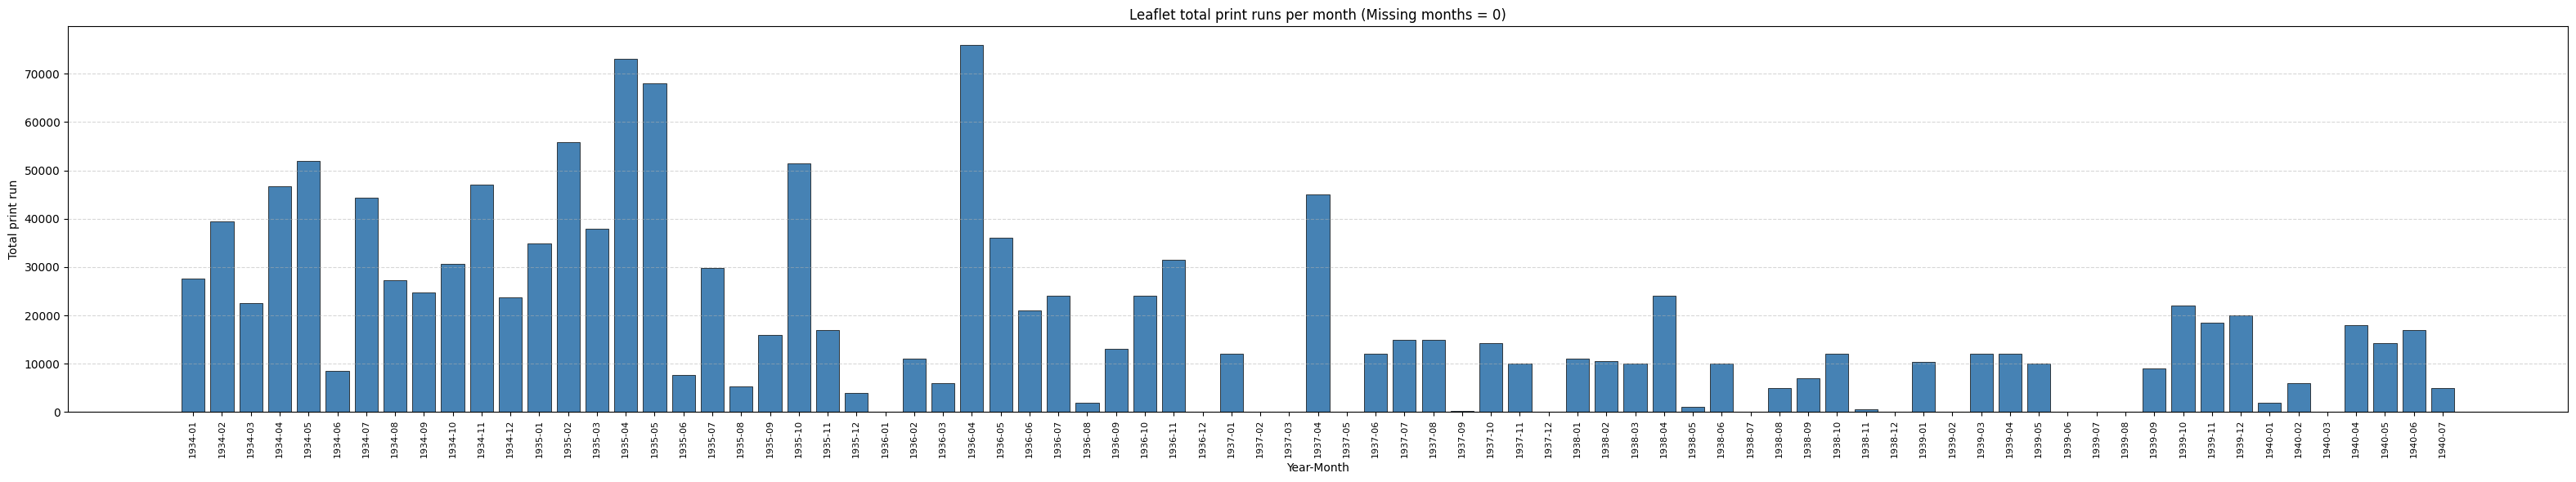

In [50]:
#@title 8) Bar chart of monthly total print runs (Missing months = 0)
import matplotlib.pyplot as plt
from datetime import datetime

# 1. Sort existing keys to find the start and end of the period
if not monthly_totals:
    print("No data available.")
else:
    sorted_existing_keys = sorted(monthly_totals.keys())

    # Convert start and end to datetime objects
    start_date = datetime.strptime(sorted_existing_keys[0], "%Y-%m")
    end_date = datetime.strptime(sorted_existing_keys[-1], "%Y-%m")

    # 2. Generate a continuous list of months (filling the gaps)
    full_labels = []
    current_date = start_date

    while current_date <= end_date:
        full_labels.append(current_date.strftime("%Y-%m"))

        # Increment month
        if current_date.month == 12:
            current_date = datetime(current_date.year + 1, 1, 1)
        else:
            current_date = datetime(current_date.year, current_date.month + 1, 1)

    # 3. Map values to the full timeline
    # If the month is in monthly_totals, use the value. If not, use 0.
    full_values = [monthly_totals.get(ym, 0) for ym in full_labels]

    # ---- Plot ----
    # Dynamic width: wider if there are many months
    plt.figure(figsize=(max(10, len(full_labels) * 0.4), 6))

    # Plot the bars
    plt.bar(range(len(full_values)), full_values, color='steelblue', edgecolor='black', linewidth=0.5)

    # Set X-axis labels
    plt.xticks(range(len(full_labels)), full_labels, rotation=90, fontsize=8)

    plt.xlabel('Year-Month')
    plt.ylabel('Total print run')
    plt.title('Leaflet total print runs per month (Missing months = 0)')

    # Add a grid for better readability of the "0" periods
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

Total unique normalized IDs: 159
Sum over years (should match): 159 

Leaflet counts per year:
1934: 63
1935: 48
1936: 17
1937: 6
1938: 3
1939: 10
1940: 12



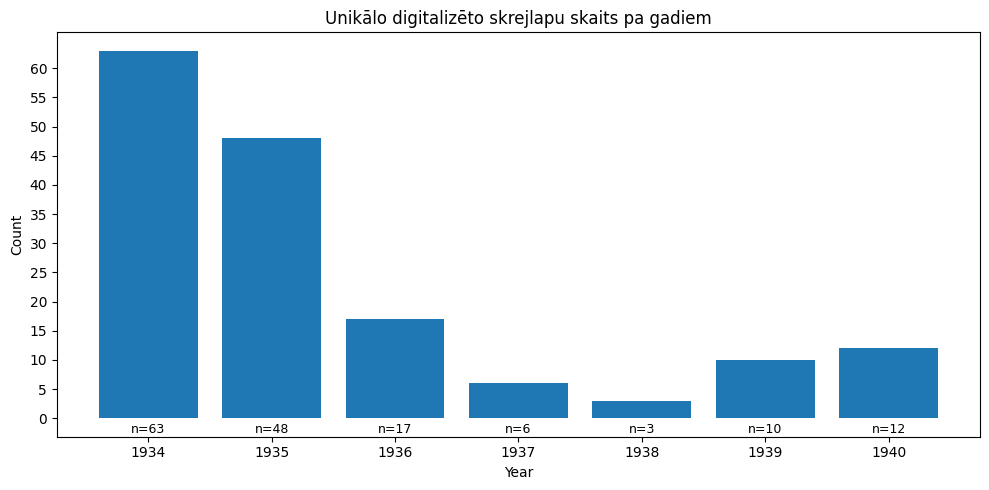

In [51]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

# Regex to extract leaflet ID (e.g., 'n197a', 'n251') from filenames like 'revl-n251-...' or 'revl-n001-...'
# FIX: Changed 'revl-' to 'lclc_ex-' to match the actual filenames.
LEAFLET_ID_RE = re.compile(r'lclc_ex-(?P<id>n\d{1,3}[a-z]?)')

def extract_leaflet_id(fname):
    """Extracts leaflet ID from filename."""
    m = LEAFLET_ID_RE.search(fname)
    if m:
        return m.group('id')
    return None

DATE_RANGE_RE = re.compile(r'(?P<y1>19\d{2})-(?P<m1>\d{2})-(?P<d1>\d{2})\.\.(?P<y2>19\d{2})-(?P<m2>\d{2})-(?P<d2>\d{2})')
DATE_FULL_RE = re.compile(r'(?P<y>19\d{2})[-_](?P<m>\d{2})[-_](?P<d>\d{2})')
DATE_YM_RE = re.compile(r'(?P<y>19\d{2})[-_](?P<m>\d{2})')

def extract_full_date_string(fname):
    """Extracts the full date string (YYYY-MM-DD or YYYY-MM) from filename."""
    m_full = DATE_FULL_RE.search(fname)
    if m_full:
        return f"{m_full.group('y')}-{m_full.group('m')}-{m_full.group('d')}"
    m_ym = DATE_YM_RE.search(fname)
    if m_ym:
        return f"{m_ym.group('y')}-{m_ym.group('m')}"
    m_range = DATE_RANGE_RE.search(fname)
    if m_range:
        return f"{m_range.group('y1')}-{m_range.group('m1')}-{m_range.group('d1')}"
    return None

def normalize_id(id_value):
    """
    Returns '197a' and '197b' as '197' to count them as single document.
    All others return the same.
    """
    match = re.search(r'(\d+)', id_value)
    if match:
        return match.group(1)
    return id_value # Return original if no digits found

# Construct a DataFrame `df` from the `filenames` list
# (assuming `filenames` is available from cell 2)
leaflet_data = []
for fname in filenames:
    leaflet_id = extract_leaflet_id(fname)
    date_str = extract_full_date_string(fname)
    # Only add to data if both ID and date are successfully extracted
    if leaflet_id and date_str:
        leaflet_data.append({'id': leaflet_id, 'date': date_str})

df = pd.DataFrame(leaflet_data)

# If no data could be parsed, raise an error or inform the user
if df.empty:
    raise SystemExit("No leaflet data could be parsed from filenames to create DataFrame with 'id' and 'date' columns.")

df["id_normalized"] = df["id"].apply(normalize_id)

# Extract year as integer from date string
df["year"] = df["date"].str[:4].astype(int)

# For each normalized ID choose one canonical year (earliest year it appears)
id_year_min = (
    df.groupby("id_normalized")["year"]
      .min()
      .reset_index(name="year_canonical")
)

# Count unique leaflets per canonical year
leaflets_per_year = (
    id_year_min.groupby("year_canonical")["id_normalized"]
               .size()
               .sort_index()
)

# Sanity checks
print("Total unique normalized IDs:", df["id_normalized"].nunique())
print("Sum over years (should match):", leaflets_per_year.sum(), "\n")

# -------- PRINT leaflet count per year --------
print("Leaflet counts per year:")
for year, count in leaflets_per_year.items():
    print(f"{year}: {count}")
print()  # empty line

# -------- Plot histogram with labels under bars --------
plt.figure(figsize=(10, 5))
x = np.arange(len(leaflets_per_year))
heights = leaflets_per_year.values

plt.bar(x, heights)

# (excluding the same 198a 198b -> 198)
plt.title("Unikālo digitalizēto skrejlapu skaits pa gadiem")
plt.xlabel("Year")
plt.ylabel("Count")

plt.xticks(x, leaflets_per_year.index.astype(str))

max_y = heights.max()
plt.yticks(np.arange(0, max_y + 1, 5))

# Shift bottom to place n=... under bars
bottom = -max_y * 0.05
plt.ylim(bottom=bottom)

# Add n= labels under each bar
for i, cnt in enumerate(heights):
    plt.text(
        i,
        bottom + max_y * 0.001,  # small offset from the bottom
        f"n={cnt}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [52]:
#@title 9) Statistical tests: ANOVA / Kruskal–Wallis
print("\n=== Statistical test: Differences between months ===")
groups = [monthly_values[ym] for ym in sorted_months if len(monthly_values[ym]) > 1]
if len(groups) < 2:
    print("Not enough data for statistical test (need ≥2 months with ≥2 values each).")
else:
    f_val, p_val_anova = stats.f_oneway(*groups)
    h_val, p_val_kw = stats.kruskal(*groups)
    print(f"ANOVA: F = {f_val:.3f}, p = {p_val_anova:.5f}")
    print(f"Kruskal–Wallis: H = {h_val:.3f}, p = {p_val_kw:.5f}")
    if p_val_kw < 0.05:
        print("→ Statistically significant difference between months (p < 0.05)")
    else:
        print("→ No significant difference between months (p ≥ 0.05)")


=== Statistical test: Differences between months ===
ANOVA: F = 2.091, p = 0.00004
Kruskal–Wallis: H = 104.964, p = 0.00004
→ Statistically significant difference between months (p < 0.05)


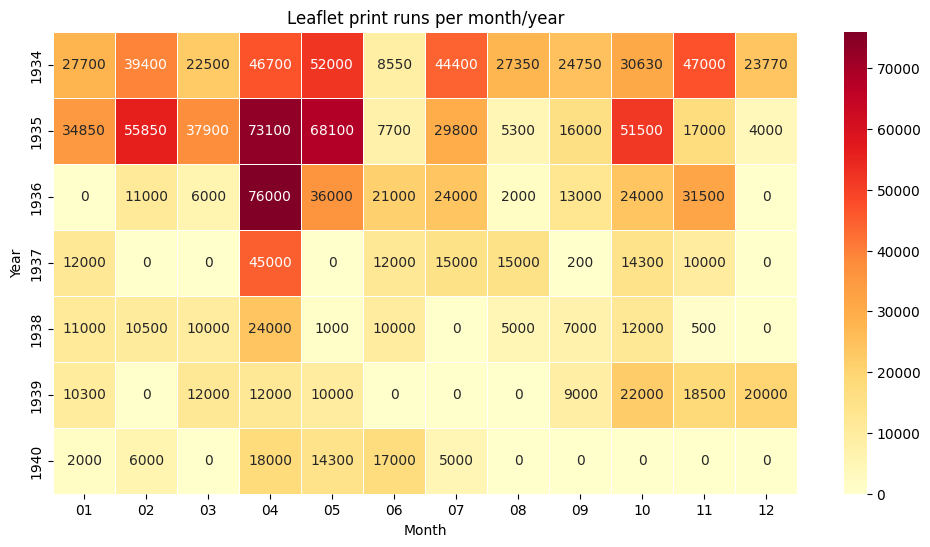

In [53]:
#@title 10) Heatmap of print runs by month and year
month_year_totals = defaultdict(int)
for ym, vals in monthly_values.items():
    y, m = ym.split('-')
    month_year_totals[(int(y), int(m))] = sum(vals)

years = sorted(set(y for y, m in month_year_totals.keys()))
months = list(range(1,13))

data = []
for y in years:
    row = [month_year_totals.get((y, m), 0) for m in months]
    data.append(row)

df = pd.DataFrame(data, index=years, columns=[f"{m:02d}" for m in months])

plt.figure(figsize=(12,6))
sns.heatmap(df, annot=True, fmt="g", cmap="YlOrRd", linewidths=0.5)
plt.title("Leaflet print runs per month/year")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()

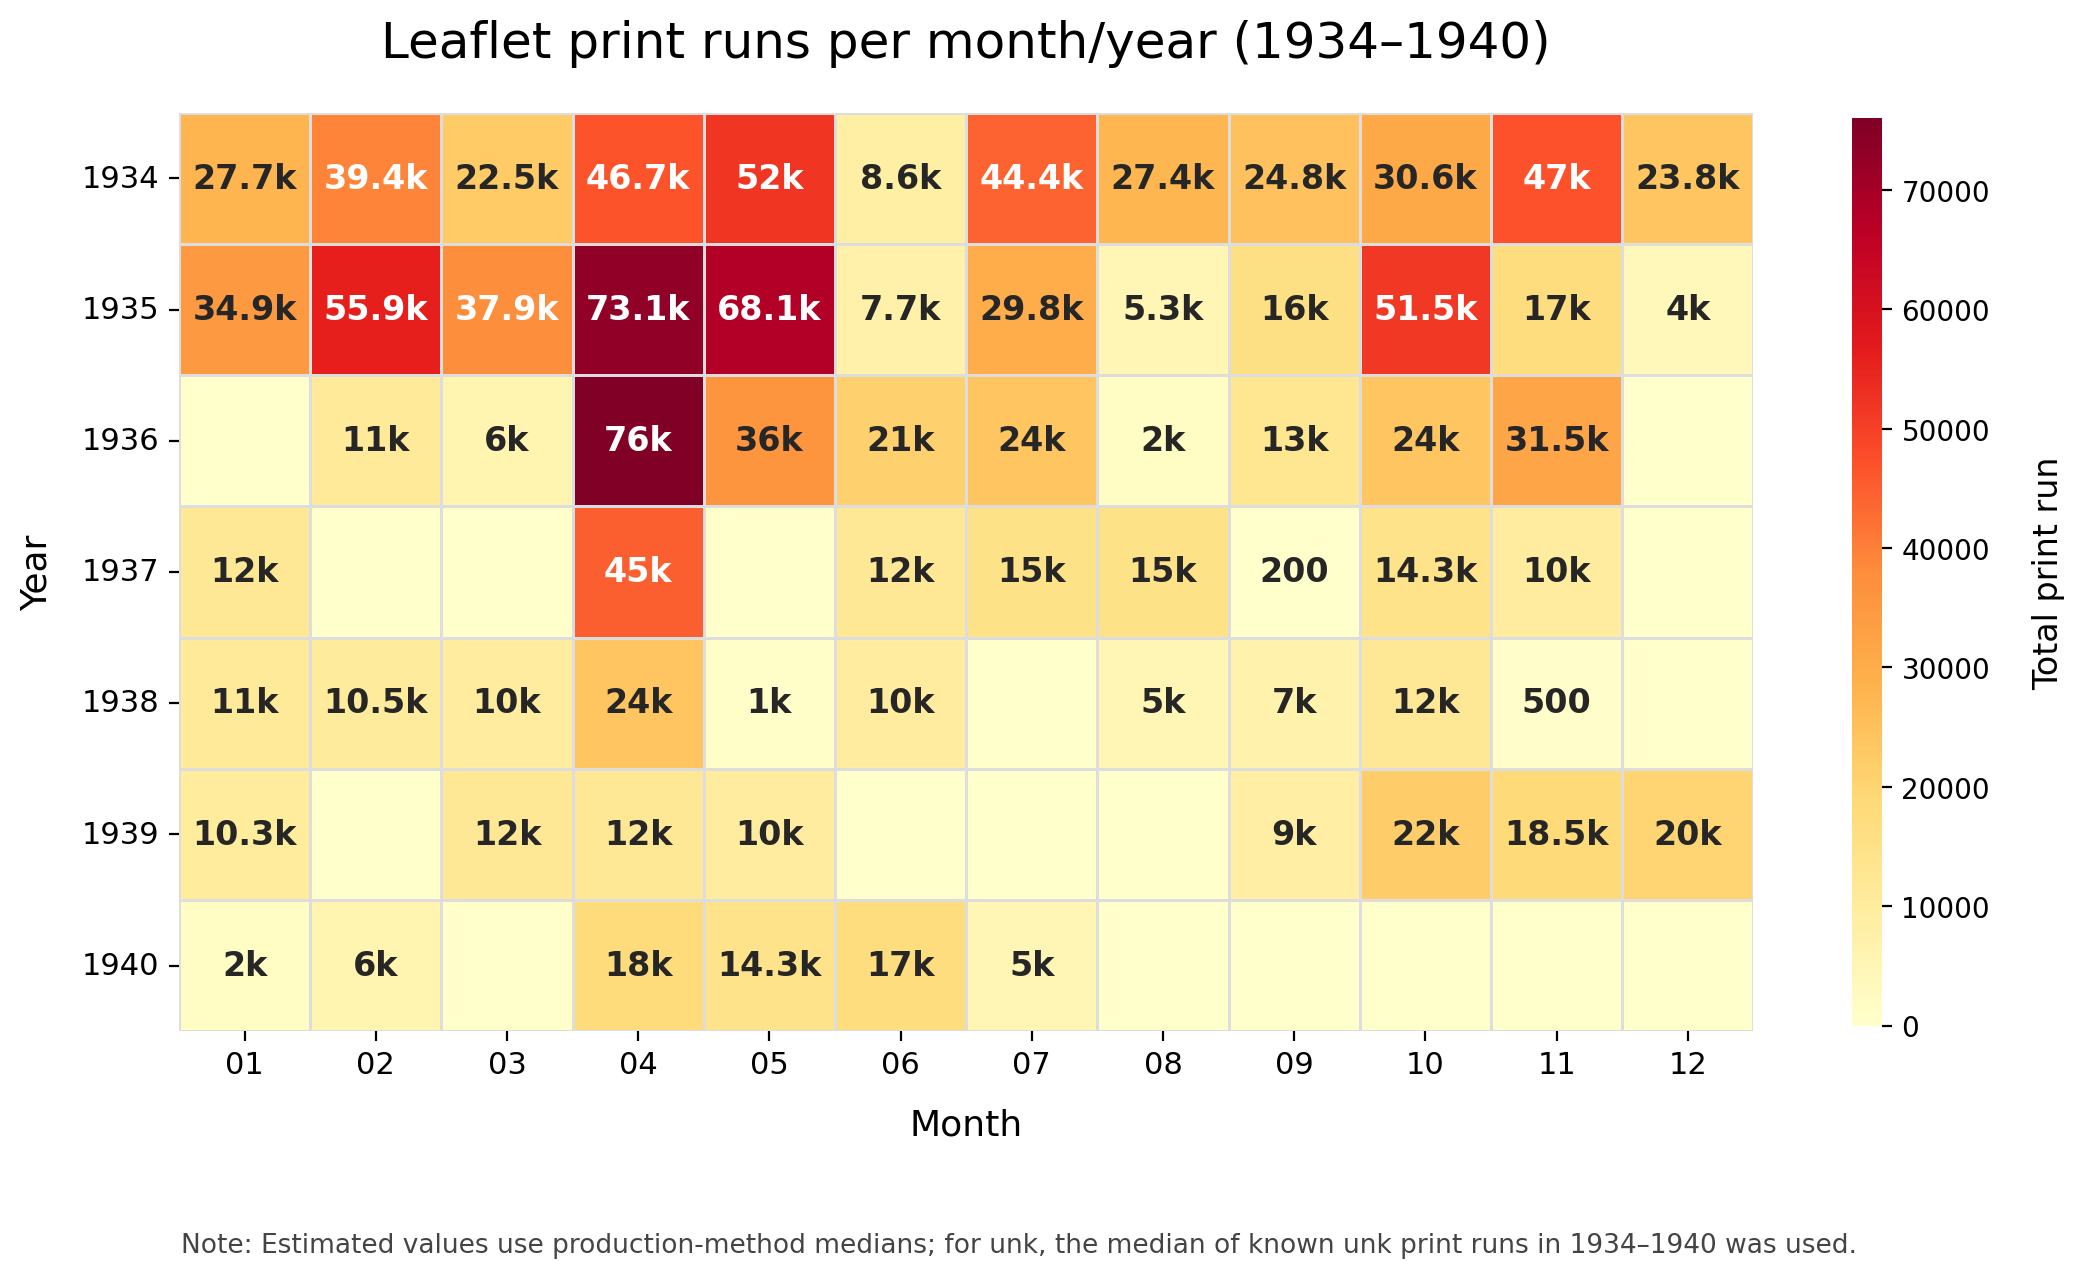

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def fmt_cell(v):
    if v == 0:
        return ""
    if v >= 1000:
        val = v / 1000
        return f"{val:.1f}k".replace(".0k", "k")
    return str(int(v))

annot_labels = df_total.copy().astype(object)
for i in range(df_total.shape[0]):
    for j in range(df_total.shape[1]):
        annot_labels.iat[i, j] = fmt_cell(df_total.iat[i, j])

fig, ax = plt.subplots(figsize=(12, 7), dpi=200)

sns.heatmap(
    df_total,
    annot=annot_labels,
    fmt="",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="#ddd",
    cbar_kws={
        "shrink": 0.9,
        "aspect": 30
    },
    annot_kws={"fontsize": 12, "fontweight": "bold"},
    ax=ax
)

ax.set_aspect("equal")

ax.set_title("Leaflet print runs per month/year (1934–1940)", fontsize=18, pad=20)
ax.set_xlabel("Month", fontsize=13, labelpad=10)
ax.set_ylabel("Year", fontsize=13, labelpad=10)

ax.set_xticklabels([f"{m:02d}" for m in months], fontsize=11, rotation=0)
ax.set_yticklabels(years, fontsize=11, rotation=0)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label("Total print run", fontsize=12, labelpad=15)

plt.figtext(
    0.43, 0.03,
    "Note: Estimated values use production-method medians; for unk, the median of known unk print runs in 1934–1940 was used.",
    ha="center",
    va="bottom",
    fontsize=9.5,
    color="#444",
    transform=fig.transFigure
)

plt.subplots_adjust(left=0.08, right=0.90, top=0.88, bottom=0.16)

plt.savefig("lclc_heatmap_clean.png", dpi=600)  # без bbox_inches="tight"
plt.show()

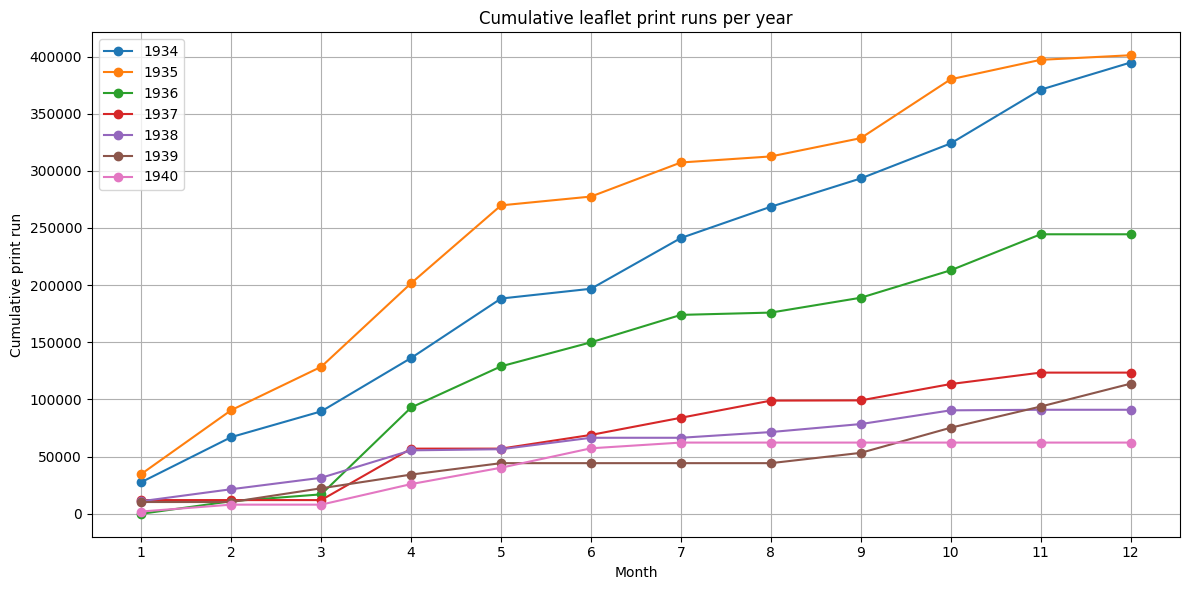

In [55]:
#@title 12) Cumulative print runs per year
year_month_totals = defaultdict(lambda: [0]*12)
for ym, vals in monthly_values.items():
    y, m = ym.split('-')
    year_month_totals[int(y)][int(m)-1] += sum(vals)

plt.figure(figsize=(12,6))
for y, month_totals in sorted(year_month_totals.items()):
    cumulative = np.cumsum(month_totals)
    plt.plot(range(1,13), cumulative, marker='o', label=str(y))

plt.xticks(range(1,13))
plt.xlabel('Month')
plt.ylabel('Cumulative print run')
plt.title('Cumulative leaflet print runs per year')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

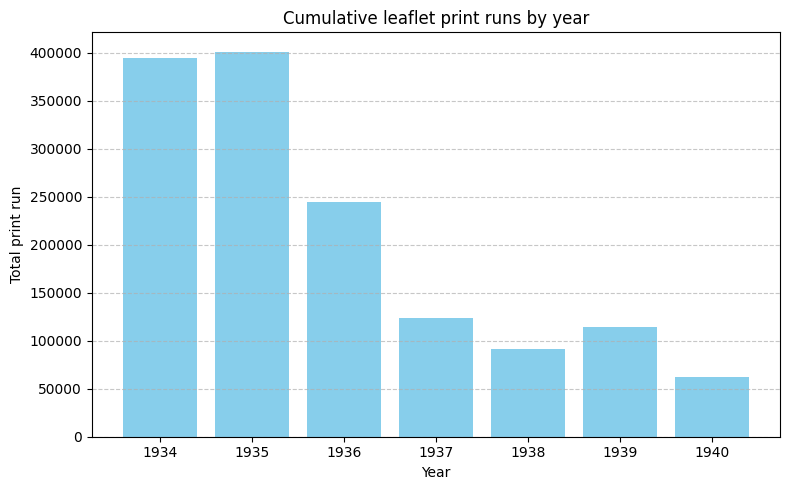

In [56]:
#@title 13) Annual cumulative print runs (simple histogram)
annual_totals = defaultdict(int)
for ym, vals in monthly_values.items():
    annual_totals[ym[:4]] += sum(vals)

years_sorted = sorted(annual_totals.keys())
totals_sorted = [annual_totals[y] for y in years_sorted]

plt.figure(figsize=(8,5))
plt.bar(years_sorted, totals_sorted, color='skyblue')
plt.xlabel('Year')
plt.ylabel('Total print run')
plt.title('Cumulative leaflet print runs by year')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

01: mean=16308, median=11500, vals=[34850, 12000, 27700, 11000, 10300, 2000]
02: mean=24550, median=11000, vals=[55850, 11000, 10500, 6000, 39400]
03: mean=17680, median=12000, vals=[22500, 37900, 12000, 6000, 10000]
04: mean=42114, median=45000, vals=[46700, 73100, 76000, 45000, 24000, 18000, 12000]
05: mean=30233, median=25150, vals=[52000, 68100, 36000, 10000, 14300, 1000]
06: mean=12708, median=11000, vals=[8550, 7700, 21000, 17000, 12000, 10000]
07: mean=23640, median=24000, vals=[44400, 5000, 29800, 24000, 15000]
08: mean=10930, median=5300, vals=[27350, 5300, 2000, 15000, 5000]
09: mean=11658, median=11000, vals=[24750, 16000, 13000, 200, 7000, 9000]
10: mean=25738, median=23000, vals=[30630, 51500, 24000, 14300, 12000, 22000]
11: mean=20750, median=17750, vals=[47000, 17000, 31500, 18500, 10000, 500]
12: mean=15923, median=20000, vals=[23770, 20000, 4000]


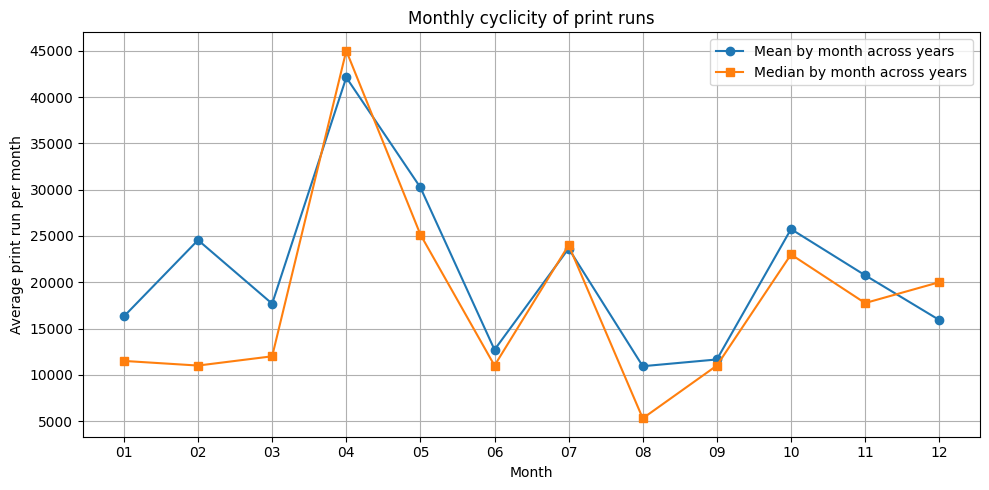

In [57]:
#@title 14) Aggregate total monthly print runs across all years
month_year_avg = defaultdict(list)

# Calculate the total print run for each month in each year
for ym, vals in monthly_values.items():
    y, m = ym.split('-')
    month_year_avg[m].append(sum(vals))

# --- Statistical Output ---

# Calculate and print mean/median for each month across all years
for m in sorted(month_year_avg.keys()):
    vals = month_year_avg[m]
    mean = int(round(np.mean(vals)))
    median = int(round(np.median(vals)))
    print(f"{m}: mean={mean}, median={median}, vals={vals}")

# --- Data Visualization ---

# Prepare data for plotting
months = sorted(month_year_avg.keys())
means = [np.mean(month_year_avg[m]) for m in months]
medians = [np.median(month_year_avg[m]) for m in months]

# Create and configure the plot
plt.figure(figsize=(10,5))
x = np.arange(len(months))
plt.plot(x, means, marker='o', label='Mean by month across years')
plt.plot(x, medians, marker='s', label='Median by month across years')
plt.xticks(x, months)
plt.xlabel('Month')
plt.ylabel('Average print run per month')
plt.title('Monthly cyclicity of print runs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

--- Statistics (Treating missing years as 0, Dividing by 7) ---
01: mean=13978, median=11000, zeros_added=1
02: mean=17535, median=10500, zeros_added=2
03: mean=12628, median=10000, zeros_added=2
04: mean=42114, median=45000, zeros_added=0
05: mean=25914, median=14300, zeros_added=1
06: mean=10892, median=10000, zeros_added=1
07: mean=16885, median=15000, zeros_added=2
08: mean=7807, median=5000, zeros_added=2
09: mean=9992, median=9000, zeros_added=1
10: mean=22061, median=22000, zeros_added=1
11: mean=17785, median=17000, zeros_added=1
12: mean=6824, median=0, zeros_added=4


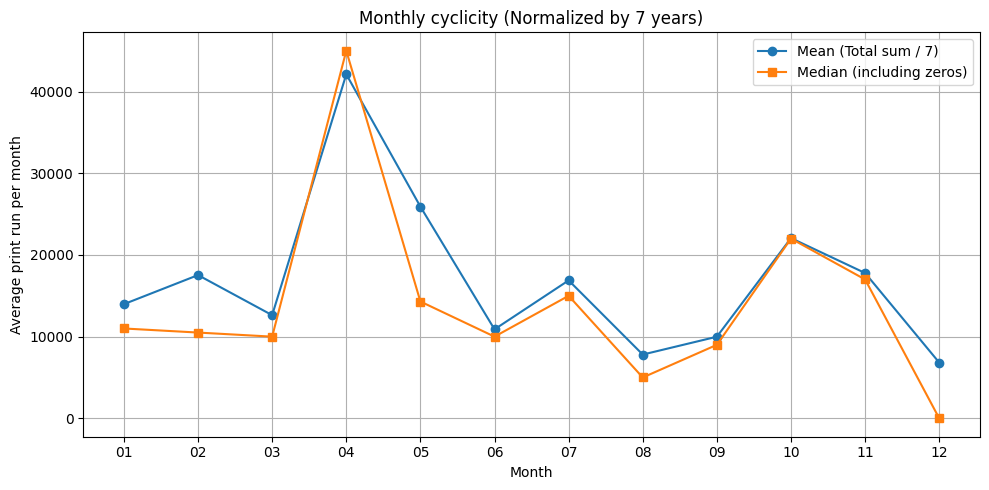

In [58]:
#@title 14) Aggregate with Zeros for Missing Years
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

TOTAL_YEARS = 7

month_year_avg = defaultdict(list)

for ym, vals in monthly_values.items():
    y, m = ym.split('-')
    month_year_avg[m].append(sum(vals))

# --- Statistical Output & Preparation ---
print(f"--- Statistics (Treating missing years as 0, Dividing by {TOTAL_YEARS}) ---")

all_months = [f"{i:02d}" for i in range(1, 13)]
means = []
medians = []

for m in all_months:
    vals = month_year_avg.get(m, [])

    missing_count = TOTAL_YEARS - len(vals)
    if missing_count > 0:
        vals.extend([0] * missing_count)

    mean_val = sum(vals) / TOTAL_YEARS
    median_val = np.median(vals)

    means.append(mean_val)
    medians.append(median_val)

    print(f"{m}: mean={int(mean_val)}, median={int(median_val)}, zeros_added={missing_count}")

# --- Data Visualization ---

plt.figure(figsize=(10, 5))
x = np.arange(len(all_months))

plt.plot(x, means, marker='o', label=f'Mean (Total sum / {TOTAL_YEARS})')
plt.plot(x, medians, marker='s', label='Median (including zeros)')

plt.xticks(x, all_months)
plt.xlabel('Month')
plt.ylabel('Average print run per month')
plt.title(f'Monthly cyclicity (Normalized by {TOTAL_YEARS} years)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


=== Tekstisks kopsavilkums pa kalendāra mēnešiem (gada kopējās tirāžas) ===

Mēnesis 01: gadu skaits = 6, gadi = [1934, 1935, 1937, 1938, 1939, 1940]
  Kopējā tirāža visos gados = 97850, vidējā = 16308, mediāna = 11500
  Min = 2000, Q1 = 10475, mediāna = 11500, Q3 = 23775, max = 34850
  IQR = 13300, apakšējā ūsas robeža = 2000, augšējā ūsas robeža = 34850
  Std = 11263, izlecēju skaits = 0, izlecēji = []

Mēnesis 02: gadu skaits = 5, gadi = [1934, 1935, 1936, 1938, 1940]
  Kopējā tirāža visos gados = 122750, vidējā = 24550, mediāna = 11000
  Min = 6000, Q1 = 10500, mediāna = 11000, Q3 = 39400, max = 55850
  IQR = 28900, apakšējā ūsas robeža = 6000, augšējā ūsas robeža = 55850
  Std = 19623, izlecēju skaits = 0, izlecēji = []

Mēnesis 03: gadu skaits = 5, gadi = [1934, 1935, 1936, 1938, 1939]
  Kopējā tirāža visos gados = 88400, vidējā = 17680, mediāna = 12000
  Min = 6000, Q1 = 10000, mediāna = 12000, Q3 = 22500, max = 37900
  IQR = 12500, apakšējā ūsas robeža = 6000, augšējā ūsas rob

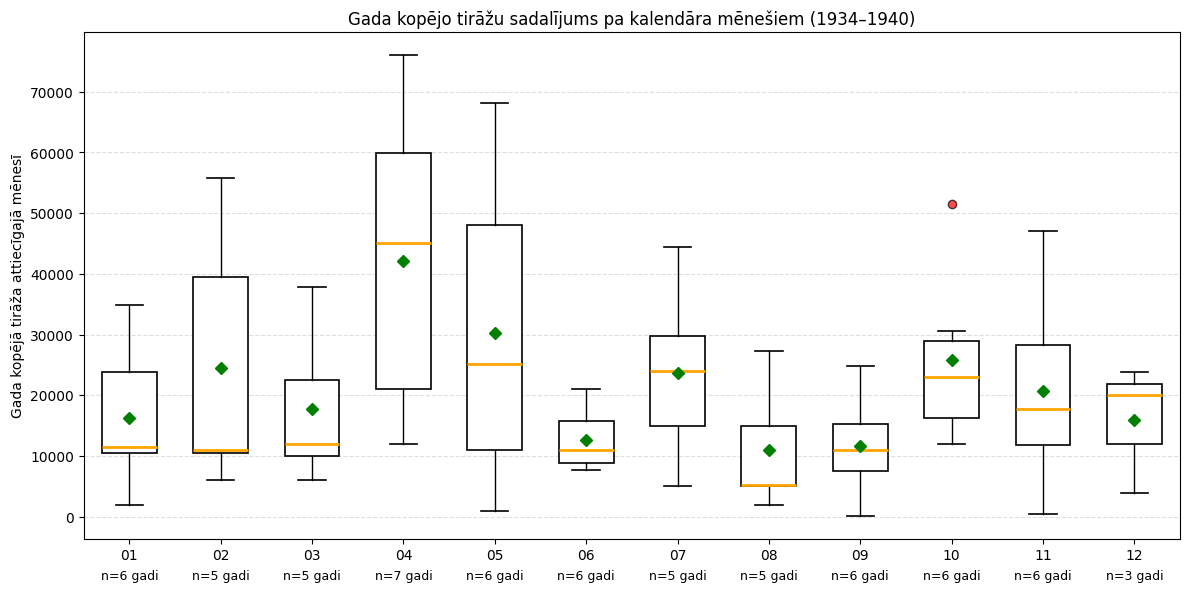

In [59]:
#@title 15) Boxplotu grafiki + mēnešu tekstiskais kopsavilkums (Tjūkija noteikumi)

import matplotlib.pyplot as plt
from collections import defaultdict, OrderedDict
import numpy as np

# Build month -> {year: sum} map (if monthly_values is per-YYYY-MM lists of leaflets' runs,
# we convert to year-summed totals per month-year)
month_year_sums = defaultdict(lambda: defaultdict(int))
for ym, vals in monthly_values.items():
    # ym like "1934-05"
    try:
        year = int(ym[:4])
        month = ym[5:7]
    except Exception:
        continue
    # interpret vals: these are already the leaflet-level values for that month-year
    # We sum them to get the total print run for that month in that year
    month_year_sums[month][year] += sum(vals)

# Prepare data for plotting and textual summary
months = [f"{i:02d}" for i in range(1,13)]
month_data = []
month_years = []  # parallel list of years lists for reference
for m in months:
    years_dict = month_year_sums.get(m, {})
    # Extract yearly totals sorted by year
    items = sorted(years_dict.items())
    vals = [v for y,v in items]
    yrs = [y for y,v in items]
    month_data.append(vals)
    month_years.append(yrs)

# Create textual summary per calendar month using Tukey definitions for whiskers
print("\n=== Tekstisks kopsavilkums pa kalendāra mēnešiem (gada kopējās tirāžas) ===\n")
for m, vals, yrs in zip(months, month_data, month_years):
    if not vals:
        # skip months with no data
        continue
    arr = np.array(vals, dtype=float)
    n = len(arr)
    total_sum = int(arr.sum())
    mean = float(arr.mean())
    median = float(np.median(arr))
    q1 = float(np.percentile(arr, 25))
    q3 = float(np.percentile(arr, 75))
    iqr = q3 - q1
    # Tukey fences
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    # whiskers: min/max within fences
    non_outliers = arr[(arr >= lower_fence) & (arr <= upper_fence)]
    if non_outliers.size > 0:
        lower_whisker = float(non_outliers.min())
        upper_whisker = float(non_outliers.max())
    else:
        # If all are outliers by Tukey rule, set whiskers to Q1/Q3 as fallback
        lower_whisker = q1
        upper_whisker = q3
    # outliers
    outlier_mask = (arr < lower_whisker) | (arr > upper_whisker)
    outliers = arr[outlier_mask].tolist()
    std = float(arr.std(ddof=0))
    mn = float(arr.min())
    mx = float(arr.max())
    # prepare textual line (latviski)
    yrs_str = ", ".join(str(y) for y in yrs) if yrs else ""
    print(f"Mēnesis {m}: gadu skaits = {n}, gadi = [{yrs_str}]")
    print(f"  Kopējā tirāža visos gados = {total_sum}, vidējā = {int(round(mean))}, mediāna = {int(round(median))}")
    print(f"  Min = {int(mn)}, Q1 = {int(round(q1))}, mediāna = {int(round(median))}, Q3 = {int(round(q3))}, max = {int(mx)}")
    print(f"  IQR = {int(round(iqr))}, apakšējā ūsas robeža = {int(round(lower_whisker))}, augšējā ūsas robeža = {int(round(upper_whisker))}")
    print(f"  Std = {int(round(std))}, izlecēju skaits = {len(outliers)}, izlecēji = {[int(round(x)) for x in outliers]}")
    print("")

# ---- Nicely styled boxplots (white boxes, black edges, orange median, green mean) ----
# Prepare cleaned lists for months that have data
months_with_data = [m for m, d in zip(months, month_data) if len(d) > 0]
data_with_data = [d for d in month_data if len(d) > 0]

fig, ax = plt.subplots(figsize=(12,6))

# boxplot settings
bp = ax.boxplot(
    data_with_data,
    tick_labels=months_with_data,
    showmeans=True,
    patch_artist=True,
    widths=0.6,
    whis=1.5,
    flierprops=dict(marker='o', markerfacecolor='red', markersize=6, linestyle='none', alpha=0.7),
    medianprops=dict(color='orange', linewidth=2),
    meanprops=dict(marker='D', markeredgecolor='green', markerfacecolor='green', markersize=6)
)

# style boxes: white fill, black edge
for box in bp['boxes']:
    box.set(facecolor='white', edgecolor='black', linewidth=1.2)
for whisker in bp['whiskers']:
    whisker.set(color='black', linewidth=1)
for cap in bp['caps']:
    cap.set(color='black', linewidth=1.2)
for median in bp['medians']:
    median.set(color='orange', linewidth=2)

ax.set_ylabel("Gada kopējā tirāža attiecīgajā mēnesī")
ax.set_title("Gada kopējo tirāžu sadalījums pa kalendāra mēnešiem (1934–1940)")
ax.grid(True, which='major', axis='y', linestyle='--', alpha=0.4)

# annotate number of years under each box for convenience
x_positions = range(1, len(months_with_data) + 1)
for x, data_vals in zip(x_positions, data_with_data):
    ax.text(
        x,
        ax.get_ylim()[0] - (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.06,
        f"n={len(data_vals)} gadi",
        ha='center',
        va='top',
        fontsize=9,
        color='black'
    )

plt.tight_layout()
plt.show()


In [60]:
#@title 16) Save CSV with detailed statistics
csv_path = "monthly_print_runs_with_stats.csv"
with open(csv_path, 'w', encoding='utf-8', newline='') as f:
    writer = csv.writer(f)

    # Column headers
    writer.writerow([
        'year_month',           # "YYYY-MM"
        'year',                 # Year as integer
        'month_number',         # Month number (1-12)
        'total_print_run',      # Total print run for that month
        'n_leaflets',           # Number of leaflets in that month
        'mean_print_run',       # Average print run
        'median_print_run',     # Median print run
        'min_print_run',        # Minimum print run
        'max_print_run',        # Maximum print run
        'std_print_run',        # Standard deviation
        'Q1',                   # First quartile (25th percentile)
        'Q3',                   # Third quartile (75th percentile)
        'IQR',                  # Interquartile range
        'n_outliers',           # Number of outliers (Tukey rule)
        'outliers',             # List of outlier values
        'change_from_prev_month',      # Absolute change from previous month
        'pct_change_from_prev_month',  # Percent change from previous month
        'cumulative_year',            # Cumulative total for that year
        'cumulative_total'            # Cumulative total across all months
    ])

    cumulative_total = 0                  # Running total for all months
    prev_total = None                     # Total of previous month for change calculation
    cumulative_year_dict = defaultdict(int)  # Dictionary for yearly cumulative totals

    for ym, vals, n_leaflets in zip(sorted_months, [monthly_values[ym] for ym in sorted_months], [monthly_counts[ym] for ym in sorted_months]):
        arr = np.array(vals, dtype=float)
        total_sum = int(arr.sum())
        mean = float(arr.mean()) if len(arr) > 0 else 0
        median = float(np.median(arr)) if len(arr) > 0 else 0
        mn = float(arr.min()) if len(arr) > 0 else 0
        mx = float(arr.max()) if len(arr) > 0 else 0
        std = float(arr.std(ddof=0)) if len(arr) > 0 else 0
        q1 = float(np.percentile(arr, 25)) if len(arr) > 0 else 0
        q3 = float(np.percentile(arr, 75)) if len(arr) > 0 else 0
        iqr = q3 - q1

        # Identify outliers using Tukey's method
        lower_fence = q1 - 1.5 * iqr
        upper_fence = q3 + 1.5 * iqr
        outlier_mask = (arr < lower_fence) | (arr > upper_fence)
        outliers = [int(round(x)) for x in arr[outlier_mask]]
        n_outliers = len(outliers)

        # Month-to-month change
        change = 0 if prev_total is None else total_sum - prev_total
        pct_change = 0 if prev_total is None or prev_total == 0 else (change / prev_total) * 100
        prev_total = total_sum

        # Yearly and overall cumulative totals
        year = int(ym[:4])
        month_number = int(ym[5:7])
        cumulative_year_dict[year] += total_sum
        cumulative_year = cumulative_year_dict[year]
        cumulative_total += total_sum

        # Write row to CSV
        writer.writerow([
            ym, year, month_number, total_sum, n_leaflets,
            round(mean,1), round(median,1), int(mn), int(mx),
            round(std,1), int(round(q1)), int(round(q3)), int(round(iqr)),
            n_outliers, str(outliers),
            int(change), round(pct_change,1),
            cumulative_year, cumulative_total
        ])

print(f"\nCSV saved to {csv_path}")
files.download(csv_path)


CSV saved to monthly_print_runs_with_stats.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>